# Dashboard Prep

Prepare the unified ads table for dashboard analysis.

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Data

In [2]:
data = pd.read_csv("data/ads_all.csv")

print(data.shape)
data.head()

(330, 26)


,platform,date,campaign_id,campaign_name,ad_group_id,ad_group_name,impressions,clicks,spend,conversions,...,cpc,quality_score,search_impression_share,video_watch_25,video_watch_50,video_watch_75,video_watch_100,likes,shares,comments
0,facebook,2024-01-01,fb_1001,Brand_Awareness_Q1,fbset_2001,Broad_Audience_18-35,45623,892,127.5,12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,facebook,2024-01-01,fb_1002,Conversions_Retargeting,fbset_2002,Cart_Abandoners,12456,567,215.8,34,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,facebook,2024-01-01,fb_1003,Traffic_Drive_Jan,fbset_2003,Lookalike_Purchasers,34567,1234,189.9,23,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,facebook,2024-01-02,fb_1001,Brand_Awareness_Q1,fbset_2001,Broad_Audience_18-35,42345,823,118.2,10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,facebook,2024-01-02,fb_1002,Conversions_Retargeting,fbset_2002,Cart_Abandoners,13678,623,234.5,38,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Validate Columns

In [3]:
required_cols = [
    "platform", "date", "campaign_id", "campaign_name",
    "ad_group_id", "ad_group_name",
    "impressions", "clicks", "spend", "conversions"
]

missing_cols = [col for col in required_cols if col not in data.columns]
missing_cols

[]

## Clean Types

In [4]:
data = data.copy()
data["date"] = pd.to_datetime(data["date"])

numeric_cols = [
    "impressions", "clicks", "spend", "conversions",
    "revenue", "video_views", "reach", "frequency",
    "likes", "shares", "comments"
]

for col in numeric_cols:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors="coerce")

if "revenue" not in data.columns:
    data["revenue"] = 0

data["revenue"] = data["revenue"].fillna(0)

## Add Metrics

In [5]:
data["ctr"] = np.where(
    data["impressions"] > 0,
    data["clicks"] / data["impressions"],
    np.nan
)

data["cpc"] = np.where(
    data["clicks"] > 0,
    data["spend"] / data["clicks"],
    np.nan
)

data["conversion_rate"] = np.where(
    data["clicks"] > 0,
    data["conversions"] / data["clicks"],
    np.nan
)

data["cpa"] = np.where(
    data["conversions"] > 0,
    data["spend"] / data["conversions"],
    np.nan
)

data["roas"] = np.where(
    data["spend"] > 0,
    data["revenue"] / data["spend"],
    np.nan
)

## Check Data

In [6]:
data[[
    "platform", "date", "campaign_name", "spend",
    "impressions", "clicks", "conversions",
    "revenue", "ctr", "cpc", "conversion_rate", "cpa", "roas"
]].head()

,platform,date,campaign_name,spend,impressions,clicks,conversions,revenue,ctr,cpc,conversion_rate,cpa,roas
0,facebook,2024-01-01,Brand_Awareness_Q1,127.5,45623,892,12,0.0,0.019552,0.142937,0.013453,10.625000,0.0
1,facebook,2024-01-01,Conversions_Retargeting,215.8,12456,567,34,0.0,0.045520,0.380600,0.059965,6.347059,0.0
2,facebook,2024-01-01,Traffic_Drive_Jan,189.9,34567,1234,23,0.0,0.035699,0.153890,0.018639,8.256522,0.0
3,facebook,2024-01-02,Brand_Awareness_Q1,118.2,42345,823,10,0.0,0.019436,0.143621,0.012151,11.820000,0.0
4,facebook,2024-01-02,Conversions_Retargeting,234.5,13678,623,38,0.0,0.045548,0.376404,0.060995,6.171053,0.0


## Data Summary

In [7]:
summary = {
    "rows": len(data),
    "start_date": data["date"].min(),
    "end_date": data["date"].max(),
    "platforms": sorted(data["platform"].dropna().unique())
}

summary

{'rows': 330,
 'start_date': Timestamp('2024-01-01 00:00:00'),
 'end_date': Timestamp('2024-01-30 00:00:00'),
 'platforms': ['facebook', 'google', 'tiktok']}

## Dashboard Data

In [8]:
def add_rate_metrics(summary_df):
    summary_df = summary_df.copy()
    summary_df["ctr"] = np.where(summary_df["impressions"] > 0, summary_df["clicks"] / summary_df["impressions"], np.nan)
    summary_df["cpc"] = np.where(summary_df["clicks"] > 0, summary_df["spend"] / summary_df["clicks"], np.nan)
    summary_df["conversion_rate"] = np.where(summary_df["clicks"] > 0, summary_df["conversions"] / summary_df["clicks"], np.nan)
    summary_df["cpa"] = np.where(summary_df["conversions"] > 0, summary_df["spend"] / summary_df["conversions"], np.nan)
    summary_df["roas"] = np.where(summary_df["spend"] > 0, summary_df["revenue"] / summary_df["spend"], np.nan)
    return summary_df

daily_summary = (
    data.groupby("date", as_index=False)
    .agg(spend=("spend", "sum"), clicks=("clicks", "sum"), conversions=("conversions", "sum"), revenue=("revenue", "sum"))
    .sort_values("date")
)

platform_summary = (
    data.groupby("platform", as_index=False)
    .agg(spend=("spend", "sum"), impressions=("impressions", "sum"), clicks=("clicks", "sum"), conversions=("conversions", "sum"), revenue=("revenue", "sum"))
    .pipe(add_rate_metrics)
    .sort_values("spend", ascending=False)
)

campaign_summary = (
    data.groupby(["platform", "campaign_name"], as_index=False)
    .agg(spend=("spend", "sum"), impressions=("impressions", "sum"), clicks=("clicks", "sum"), conversions=("conversions", "sum"), revenue=("revenue", "sum"))
    .pipe(add_rate_metrics)
    .sort_values("spend", ascending=False)
)

platform_summary

,platform,spend,impressions,clicks,conversions,revenue,ctr,cpc,conversion_rate,cpa,roas
2,tiktok,74266.7,28708167,461844,6750,0.0,0.016088,0.160805,0.014615,11.002474,0.000000
1,google,37686.2,7223544,137590,4218,210900.0,0.019047,0.273902,0.030656,8.934614,5.596213
0,facebook,18292.0,4541474,88899,2395,0.0,0.019575,0.205762,0.026941,7.637578,0.000000


## Dashboard Preview

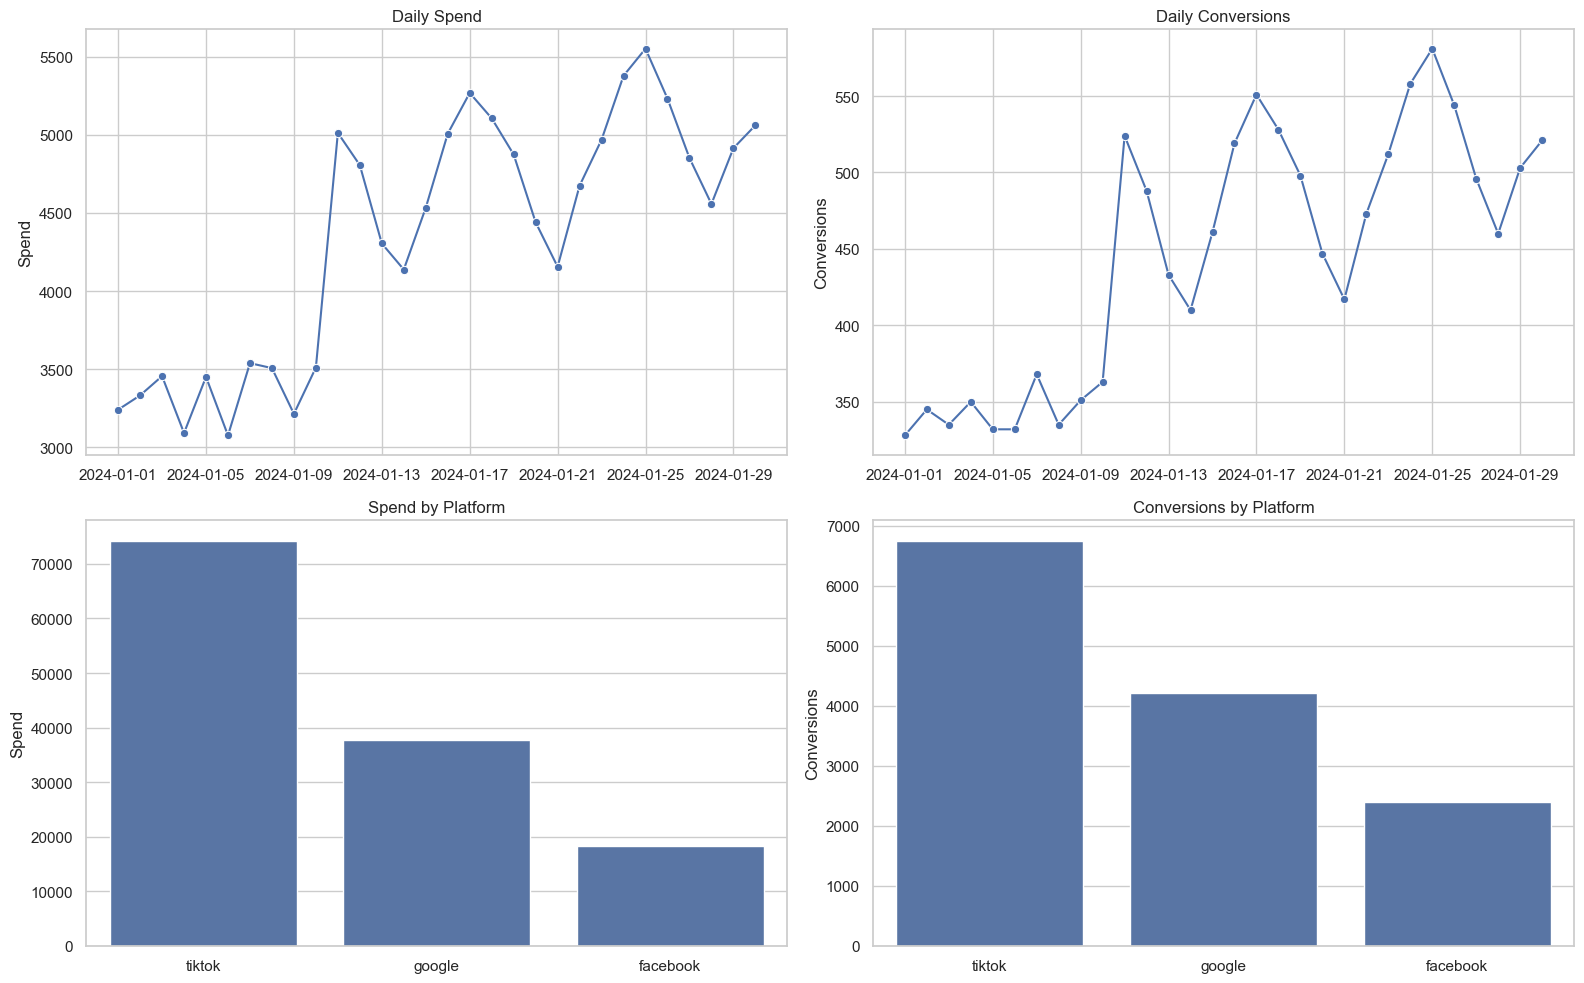

In [9]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.lineplot(data=daily_summary, x="date", y="spend", marker="o", ax=axes[0, 0])
axes[0, 0].set_title("Daily Spend")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Spend")

sns.lineplot(data=daily_summary, x="date", y="conversions", marker="o", ax=axes[0, 1])
axes[0, 1].set_title("Daily Conversions")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Conversions")

sns.barplot(data=platform_summary, x="platform", y="spend", ax=axes[1, 0])
axes[1, 0].set_title("Spend by Platform")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Spend")

sns.barplot(data=platform_summary, x="platform", y="conversions", ax=axes[1, 1])
axes[1, 1].set_title("Conversions by Platform")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Conversions")

plt.tight_layout()
plt.show()

## Campaign Table

In [ ]:
campaign_summary[[
    "platform", "campaign_name", "spend", "impressions", "clicks",
    "conversions", "revenue", "ctr", "cpc", "conversion_rate", "cpa", "roas"
]].round(4)

## Streamlit App

In [ ]:
print("Dashboard app file: streamlit_app.py")
print("Local command: streamlit run streamlit_app.py")